# Lab Assignment 5


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


In [ ]:
from ucimlrepo import fetch_ucirepo

vertebral_column = fetch_ucirepo(id=212)

X = vertebral_column.data.features.copy()
y = vertebral_column.data.targets.copy()

print("METADATA")
print(vertebral_column.metadata)

print("\nVARIABLE INFORMATION")
display(vertebral_column.variables)

print("\nFEATURES SHAPE:", X.shape)
print("TARGET SHAPE:", y.shape)

display(X.head())
display(y.head())


METADATA
{'uci_id': 212, 'name': 'Vertebral Column', 'repository_url': 'https://archive.ics.uci.edu/dataset/212/vertebral+column', 'data_url': 'https://archive.ics.uci.edu/static/public/212/data.csv', 'abstract': 'Data set containing values for six biomechanical features used to classify orthopaedic patients into 3 classes (normal, disk hernia or spondilolysthesis) or 2 classes (normal or abnormal).', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 310, 'num_features': 6, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2005, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C5K89B', 'creators': ['Guilherme Barreto', 'Ajalmar Neto'], 'intro_paper': None, 'additional_info': {'summary': "Biomedical data set built by Dr. Henrique da Mota during a medical residence period in the Group of 

,name,role,type,demographic,description,units,missing_values
0,pelvic_incidence,Feature,Continuous,None,None,None,no
1,pelvic_tilt,Feature,Continuous,None,None,None,no
2,lumbar_lordosis_angle,Feature,Continuous,None,None,None,no
3,sacral_slope,Feature,Continuous,None,None,None,no
4,pelvic_radius,Feature,Continuous,None,None,None,no
5,degree_spondylolisthesis,Feature,Continuous,None,None,None,no
6,class,Target,Categorical,None,None,None,no



FEATURES SHAPE: (310, 6)
TARGET SHAPE: (310, 1)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501


,class
0,Hernia
1,Hernia
2,Hernia
3,Hernia
4,Hernia


## Task 1 — Data Acquisition and Exploration

In [ ]:
print("Feature information:")
display(X.info())

print("\nTarget information:")
display(y.info())

print("\nFeature data types:")
display(X.dtypes)

print("\nTarget data types:")
display(y.dtypes)


Feature information:
<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
dtypes: float64(6)
memory usage: 14.7 KB


None


Target information:
<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   310 non-null    str  
dtypes: str(1)
memory usage: 6.0 KB


None


Feature data types:


pelvic_incidence            float64
pelvic_tilt                 float64
lumbar_lordosis_angle       float64
sacral_slope                float64
pelvic_radius               float64
degree_spondylolisthesis    float64
dtype: object


Target data types:


class    str
dtype: object

In [ ]:
target_column = y.columns[0]
print("Target column:", target_column)

X.columns = [str(col).strip() for col in X.columns]
y.columns = [str(col).strip() for col in y.columns]

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

print("Summary statistics for all features:")
display(X.describe().T)

print("Additional statistics:")
additional_stats = pd.DataFrame({
    "median": X.median(),
    "variance": X.var(),
    "missing_values": X.isna().sum(),
    "unique_values": X.nunique()
})
display(additional_stats)


Target column: class
Summary statistics for all features:


,count,mean,std,min,25%,50%,75%,max
pelvic_incidence,310.0,60.496653,17.236520,26.147921,46.430294,58.691038,72.877696,129.834041
pelvic_tilt,310.0,17.542822,10.008330,-6.554948,10.667069,16.357689,22.120395,49.431864
lumbar_lordosis_angle,310.0,51.930930,18.554064,14.000000,37.000000,49.562398,63.000000,125.742385
sacral_slope,310.0,42.953831,13.423102,13.366931,33.347122,42.404912,52.695888,121.429566
pelvic_radius,310.0,117.920655,13.317377,70.082575,110.709196,118.268178,125.467674,163.071041
degree_spondylolisthesis,310.0,26.296694,37.559027,-11.058179,1.603727,11.767934,41.287352,418.543082


Additional statistics:


,median,variance,missing_values,unique_values
pelvic_incidence,58.691038,297.097633,0,310
pelvic_tilt,16.357689,100.166675,0,310
lumbar_lordosis_angle,49.562398,344.253290,0,280
sacral_slope,42.404912,180.179672,0,281
pelvic_radius,118.268178,177.352531,0,310
degree_spondylolisthesis,11.767934,1410.680476,0,310


In [ ]:
print("Missing values in features:")
display(X.isna().sum())

print("Missing values in target:")
display(y.isna().sum())

print("Duplicate feature rows:", X.duplicated().sum())
print("Duplicate complete rows:", pd.concat([X, y], axis=1).duplicated().sum())


Missing values in features:


pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
dtype: int64

Missing values in target:


class    0
dtype: int64

Duplicate feature rows: 0
Duplicate complete rows: 0


In [ ]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

valid_target_mask = y[target_column].notna()
X_imputed = X_imputed.loc[valid_target_mask].copy()
y_clean = y.loc[valid_target_mask].copy()

print("Shape after missing-value handling:", X_imputed.shape, y_clean.shape)


Shape after missing-value handling: (310, 6) (310, 1)


In [ ]:
def iqr_outlier_summary(dataframe):
    rows = []
    for col in dataframe.columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        count = ((dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)).sum()
        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(count)
        })
    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(X_imputed)
display(outlier_summary)


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,pelvic_incidence,46.430294,72.877696,26.447401,6.759192,112.548797,3
1,pelvic_tilt,10.667069,22.120395,11.453326,-6.512919,39.300383,13
2,lumbar_lordosis_angle,37.000000,63.000000,26.000000,-2.000000,102.000000,1
3,sacral_slope,33.347122,52.695888,19.348766,4.323972,81.719038,1
4,pelvic_radius,110.709196,125.467674,14.758478,88.571479,147.605392,11
5,degree_spondylolisthesis,1.603727,41.287352,39.683625,-57.921711,100.812790,10


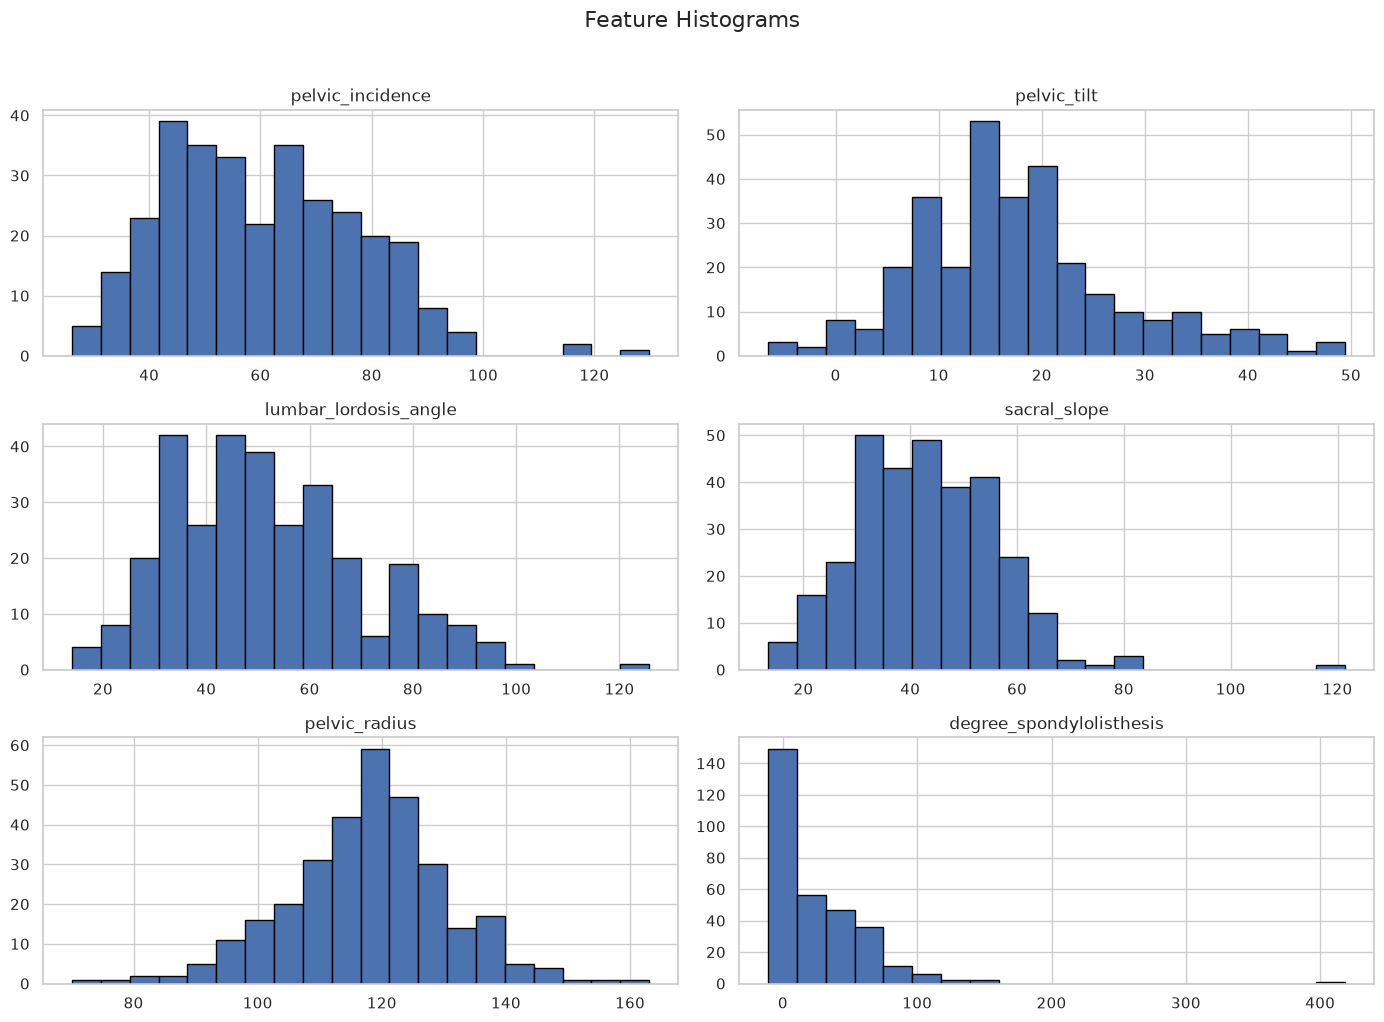

In [ ]:
X_imputed.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Histograms", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


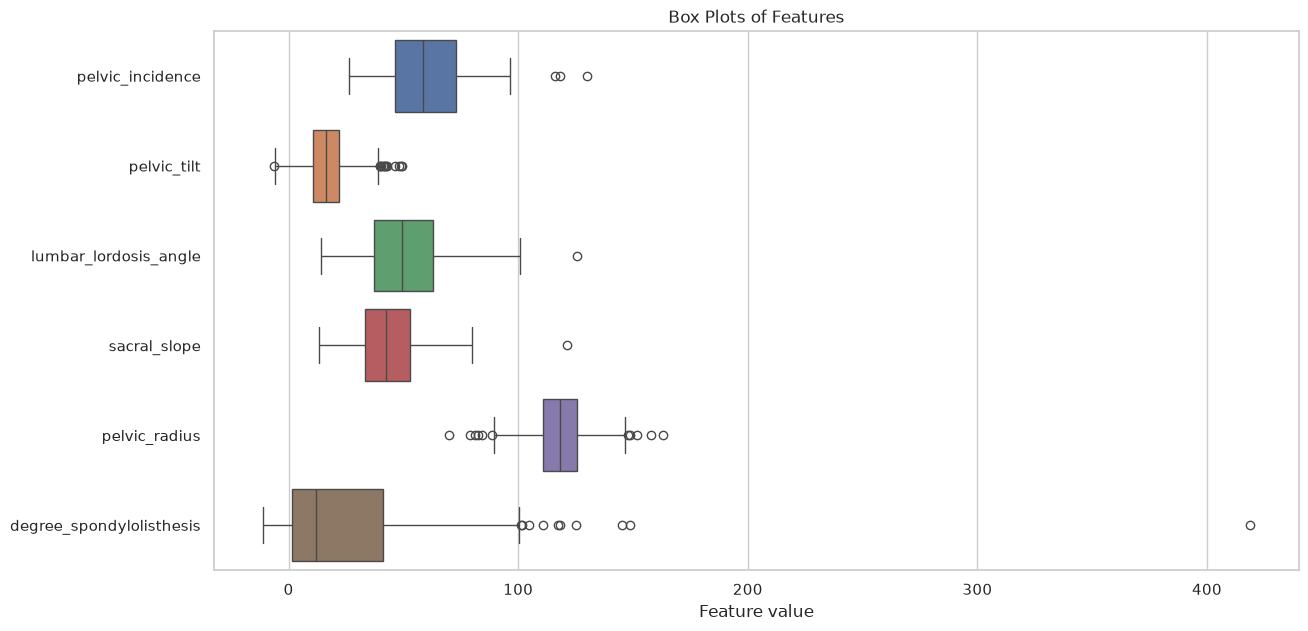

In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=X_imputed, orient="h")
plt.title("Box Plots of Features")
plt.xlabel("Feature value")
plt.show()


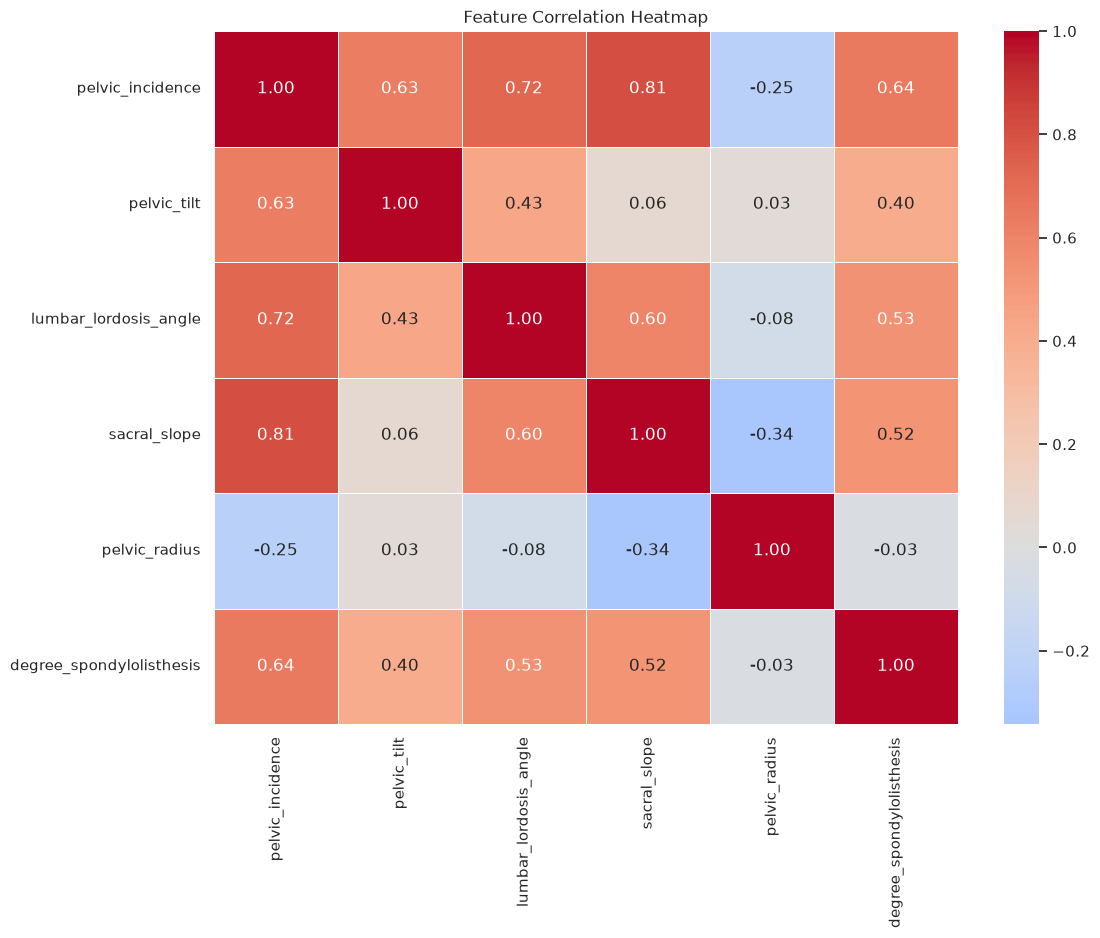

In [ ]:
plt.figure(figsize=(12, 9))
correlation_matrix = X_imputed.corr(numeric_only=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()


Class counts:


class
Hernia                60
Normal               100
Spondylolisthesis    150
Name: count, dtype: int64

Class proportions:


class
Hernia               19.35
Normal               32.26
Spondylolisthesis    48.39
Name: percentage, dtype: float64

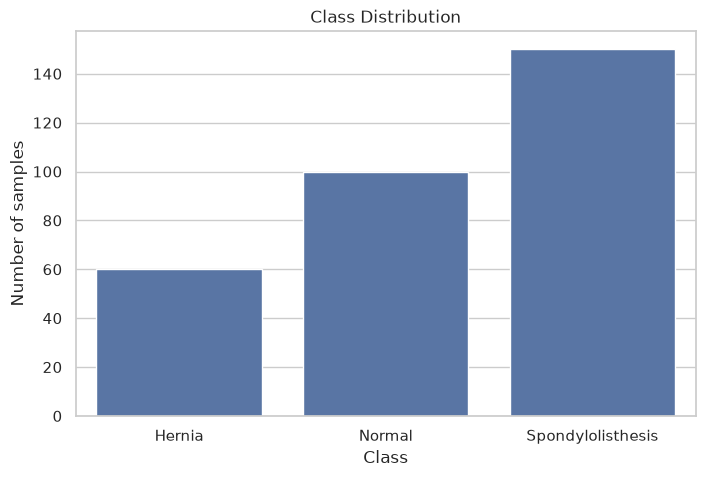

In [ ]:
print("Class counts:")
display(y_clean[target_column].value_counts().sort_index())

print("Class proportions:")
display(
    y_clean[target_column]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .rename("percentage")
)

plt.figure(figsize=(8, 5))
sns.countplot(
    x=y_clean[target_column].astype(str),
    order=sorted(y_clean[target_column].astype(str).unique())
)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.show()


## Task 2 — Data Preprocessing

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_clean[target_column])

class_names = label_encoder.classes_
n_classes = len(class_names)

print("Original class labels:", list(class_names))
print("Encoded class labels:", list(range(n_classes)))


Original class labels: ['Hernia', 'Normal', 'Spondylolisthesis']
Encoded class labels: [0, 1, 2]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


Training set: (248, 6)
Testing set: (62, 6)

Training class distribution:
0    0.193548
1    0.322581
2    0.483871
Name: proportion, dtype: float64

Testing class distribution:
0    0.193548
1    0.322581
2    0.483871
Name: proportion, dtype: float64


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)


Scaled training shape: (248, 6)
Scaled testing shape: (62, 6)


## Task 3 — Model Training and Basic Evaluation

In [ ]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Linear SVM": SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

trained_models = {}
results = []
predictions = {}
probabilities = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    trained_models[model_name] = model
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-score (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "AUC (OvR, macro)": roc_auc_score(
            y_test, y_prob, multi_class="ovr", average="macro"
        )
    })

results_df = pd.DataFrame(results).sort_values(
    by="F1-score (macro)", ascending=False
).reset_index(drop=True)

display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision (macro)": "{:.4f}",
    "Recall (macro)": "{:.4f}",
    "F1-score (macro)": "{:.4f}",
    "AUC (OvR, macro)": "{:.4f}"
}))


,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro),"AUC (OvR, macro)"
0,Random Forest,0.8710,0.8381,0.8500,0.8418,0.9398
1,Linear SVM,0.8387,0.8009,0.8222,0.8055,0.9564
2,Logistic Regression,0.8226,0.7937,0.8167,0.8003,0.9376
3,SVM,0.8065,0.7828,0.8056,0.7880,0.9323
4,KNN,0.7097,0.6980,0.6889,0.6815,0.8581


In [ ]:
for model_name, y_pred in predictions.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[str(c) for c in class_names],
            zero_division=0
        )
    )


KNN
                   precision    recall  f1-score   support

           Hernia       0.54      0.58      0.56        12
           Normal       0.56      0.75      0.64        20
Spondylolisthesis       1.00      0.73      0.85        30

         accuracy                           0.71        62
        macro avg       0.70      0.69      0.68        62
     weighted avg       0.77      0.71      0.72        62

Random Forest
                   precision    recall  f1-score   support

           Hernia       0.71      0.83      0.77        12
           Normal       0.83      0.75      0.79        20
Spondylolisthesis       0.97      0.97      0.97        30

         accuracy                           0.87        62
        macro avg       0.84      0.85      0.84        62
     weighted avg       0.87      0.87      0.87        62

Logistic Regression
                   precision    recall  f1-score   support

           Hernia       0.67      0.83      0.74        12
           

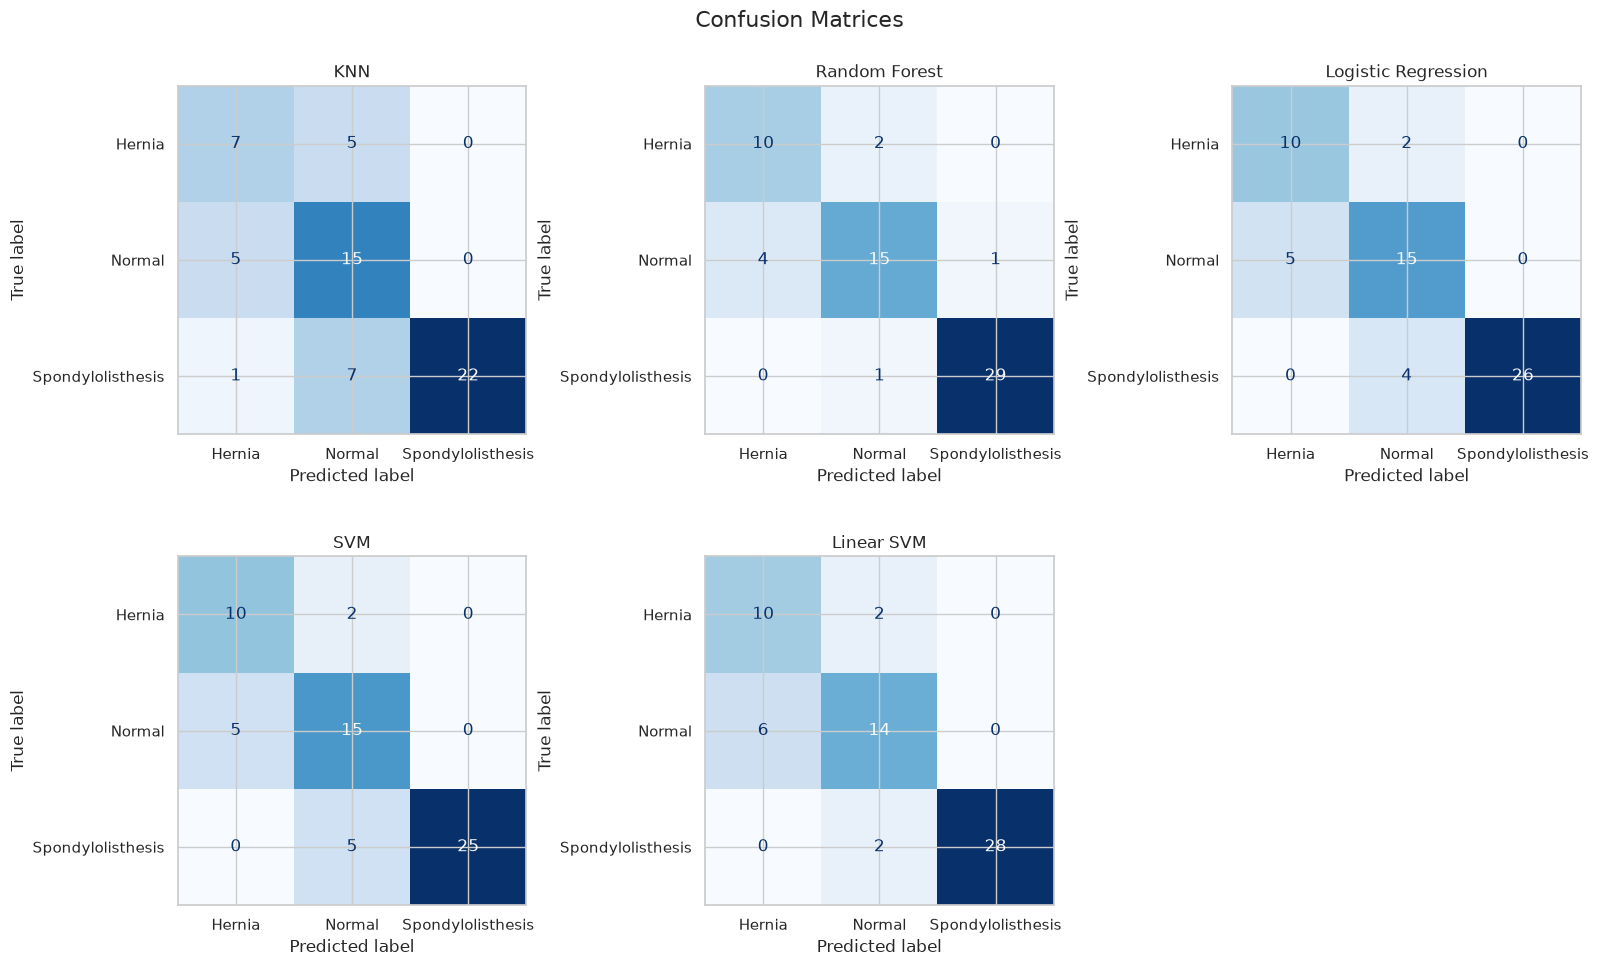

In [ ]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 10)
)
axes = axes.ravel()

for ax, (model_name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(model_name)

for ax in axes[len(predictions):]:
    ax.axis("off")

plt.suptitle("Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.show()


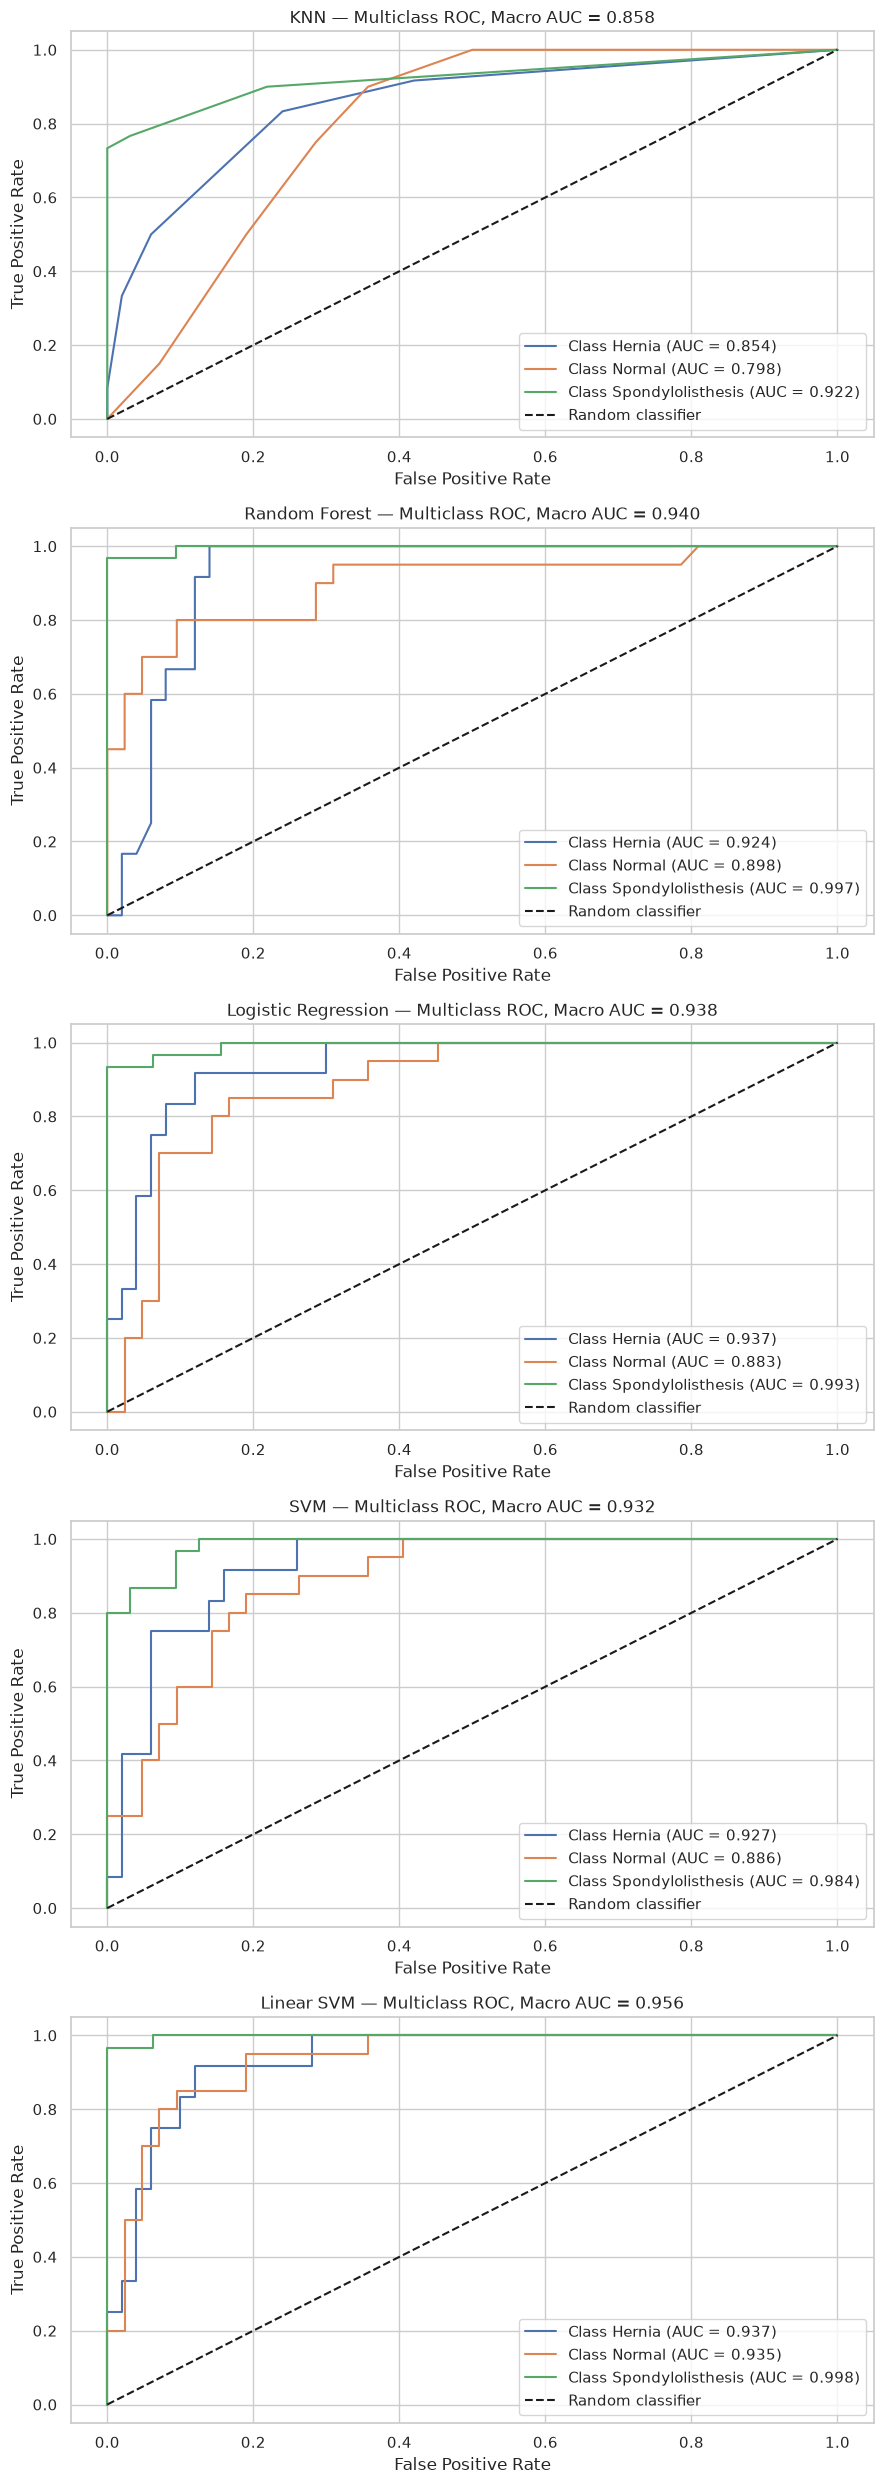

In [ ]:
y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes))

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=1,
    figsize=(9, 5 * len(models))
)

if len(models) == 1:
    axes = [axes]

for ax, (model_name, y_prob) in zip(axes, probabilities.items()):
    for class_index, class_label in enumerate(class_names):
        fpr, tpr, _ = roc_curve(
            y_test_binarized[:, class_index],
            y_prob[:, class_index]
        )
        class_auc = auc(fpr, tpr)
        ax.plot(
            fpr,
            tpr,
            label=f"Class {class_label} (AUC = {class_auc:.3f})"
        )

    macro_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set_title(f"{model_name} — Multiclass ROC, Macro AUC = {macro_auc:.3f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True)

plt.tight_layout()
plt.show()


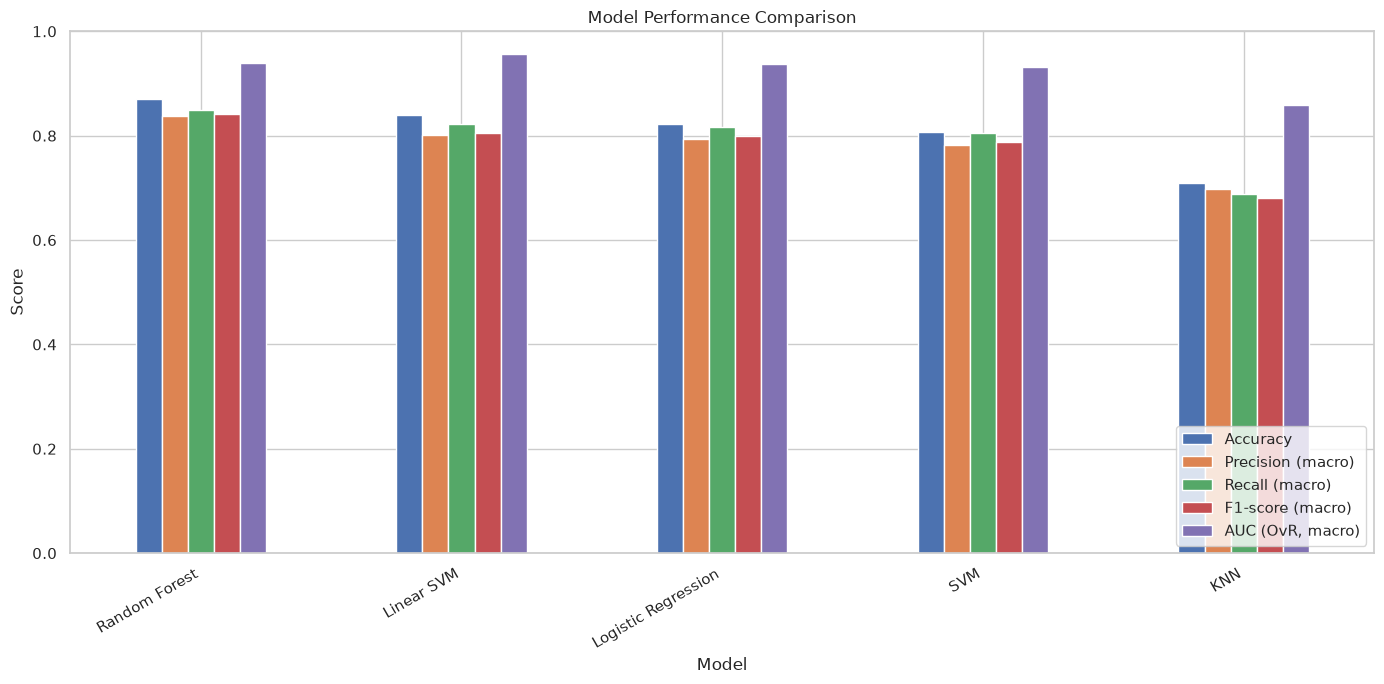

In [ ]:
metrics_to_plot = [
    "Accuracy",
    "Precision (macro)",
    "Recall (macro)",
    "F1-score (macro)",
    "AUC (OvR, macro)"
]

plot_df = results_df.set_index("Model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(14, 7), ylim=(0, 1))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
best_f1_model = results_df.loc[results_df["F1-score (macro)"].idxmax(), "Model"]
best_auc_model = results_df.loc[results_df["AUC (OvR, macro)"].idxmax(), "Model"]
best_accuracy_model = results_df.loc[results_df["Accuracy"].idxmax(), "Model"]

print("Best model by macro F1-score:", best_f1_model)
print("Best model by macro AUC:", best_auc_model)
print("Best model by accuracy:", best_accuracy_model)

print("\nSuggested conclusion:")
print(
    f"The model with the highest macro F1-score was {best_f1_model}. "
    f"The model with the highest macro AUC was {best_auc_model}, while "
    f"the highest accuracy was achieved by {best_accuracy_model}. "
    "The final choice should consider class-wise recall, the confusion matrix, "
    "and the clinical cost of different classification errors."
)


Best model by macro F1-score: Random Forest
Best model by macro AUC: Linear SVM
Best model by accuracy: Random Forest

Suggested conclusion:
The model with the highest macro F1-score was Random Forest. The model with the highest macro AUC was Linear SVM, while the highest accuracy was achieved by Random Forest. The final choice should consider class-wise recall, the confusion matrix, and the clinical cost of different classification errors.
